<a href="https://colab.research.google.com/github/petkimani/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction_with_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Gathering & Exploration

In [ ]:
!pip install ydata-profiling
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=42fb6cc459463754f2cf1c20447c9e8ced08ad7b1910735b9a1ae0d44055117e
  Stored in directory: /root/.cache/pip/wheels/5f/d4/d7/4189b07b5902ee9f3ce0dbb14909fbe8037c39d6c63ffd49c9
Successfully built htmlmin
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
     

In [ ]:
# Import Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style('darkgrid')

In [ ]:
# Load the dataset
heart_df = pd.read_csv('/content/heart.csv')
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# display unique values in "ChestPainType"
heart_df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [ ]:
# Display information of the dataset
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# describe the dataset
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


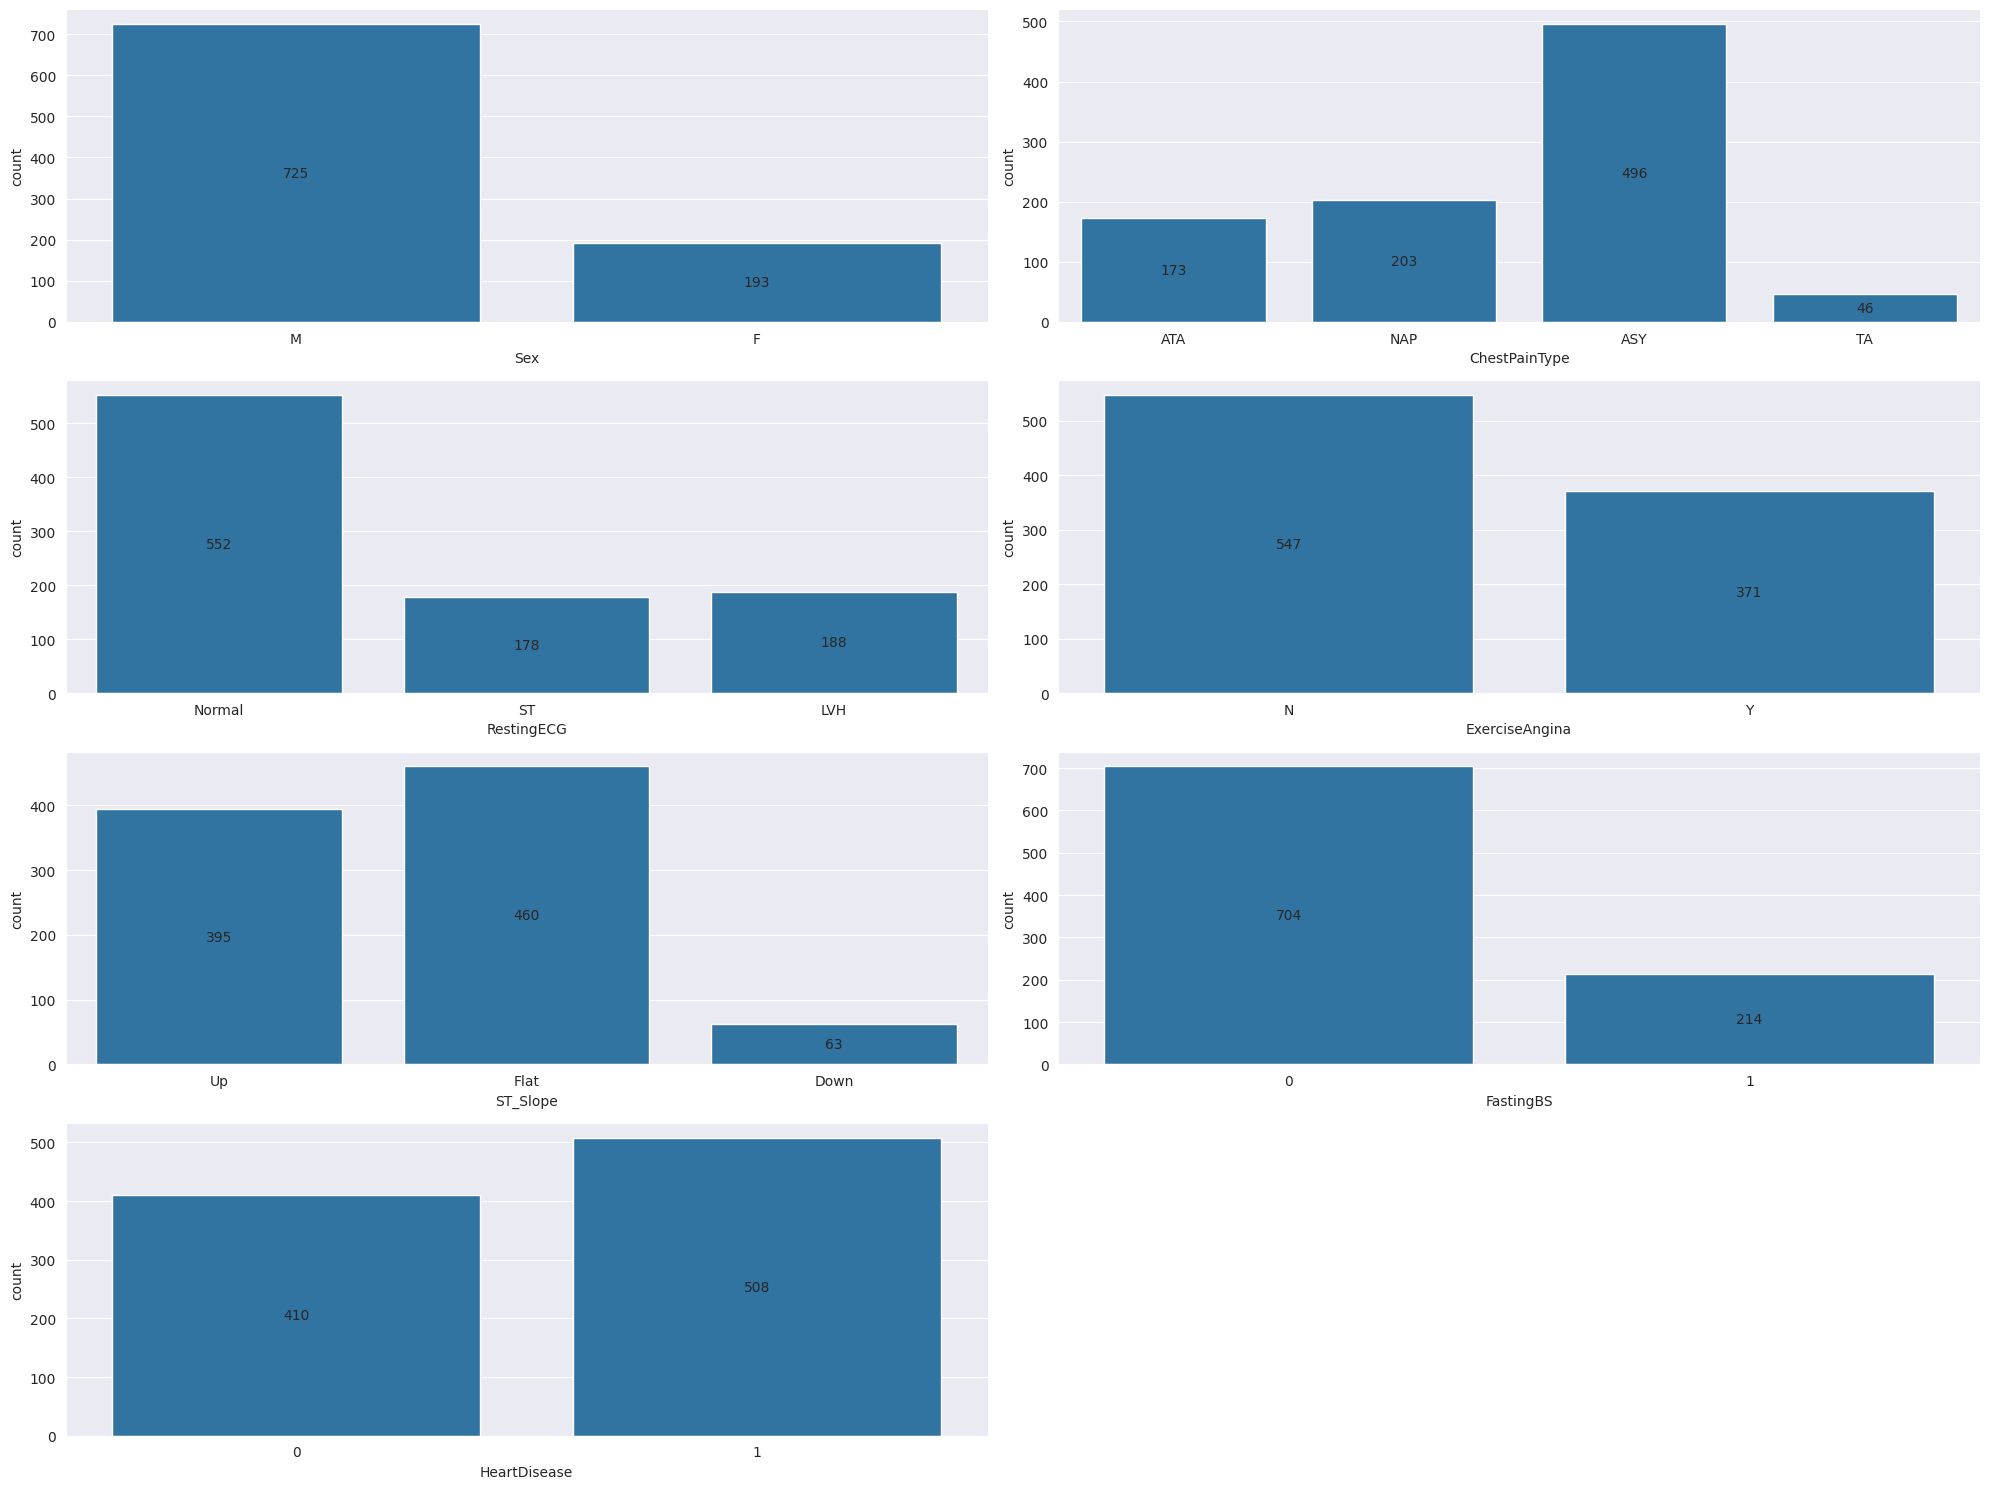

In [ ]:
# do some predictive analysis on categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS', 'HeartDisease']

fig = plt.figure(figsize=(20, 15))

for idx, col in enumerate(categorical_cols):
  ax = plt.subplot(4, 2, idx + 1)
  sns.countplot(x=heart_df[col], ax=ax)
  # add data labels to each bar
  for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.tight_layout()

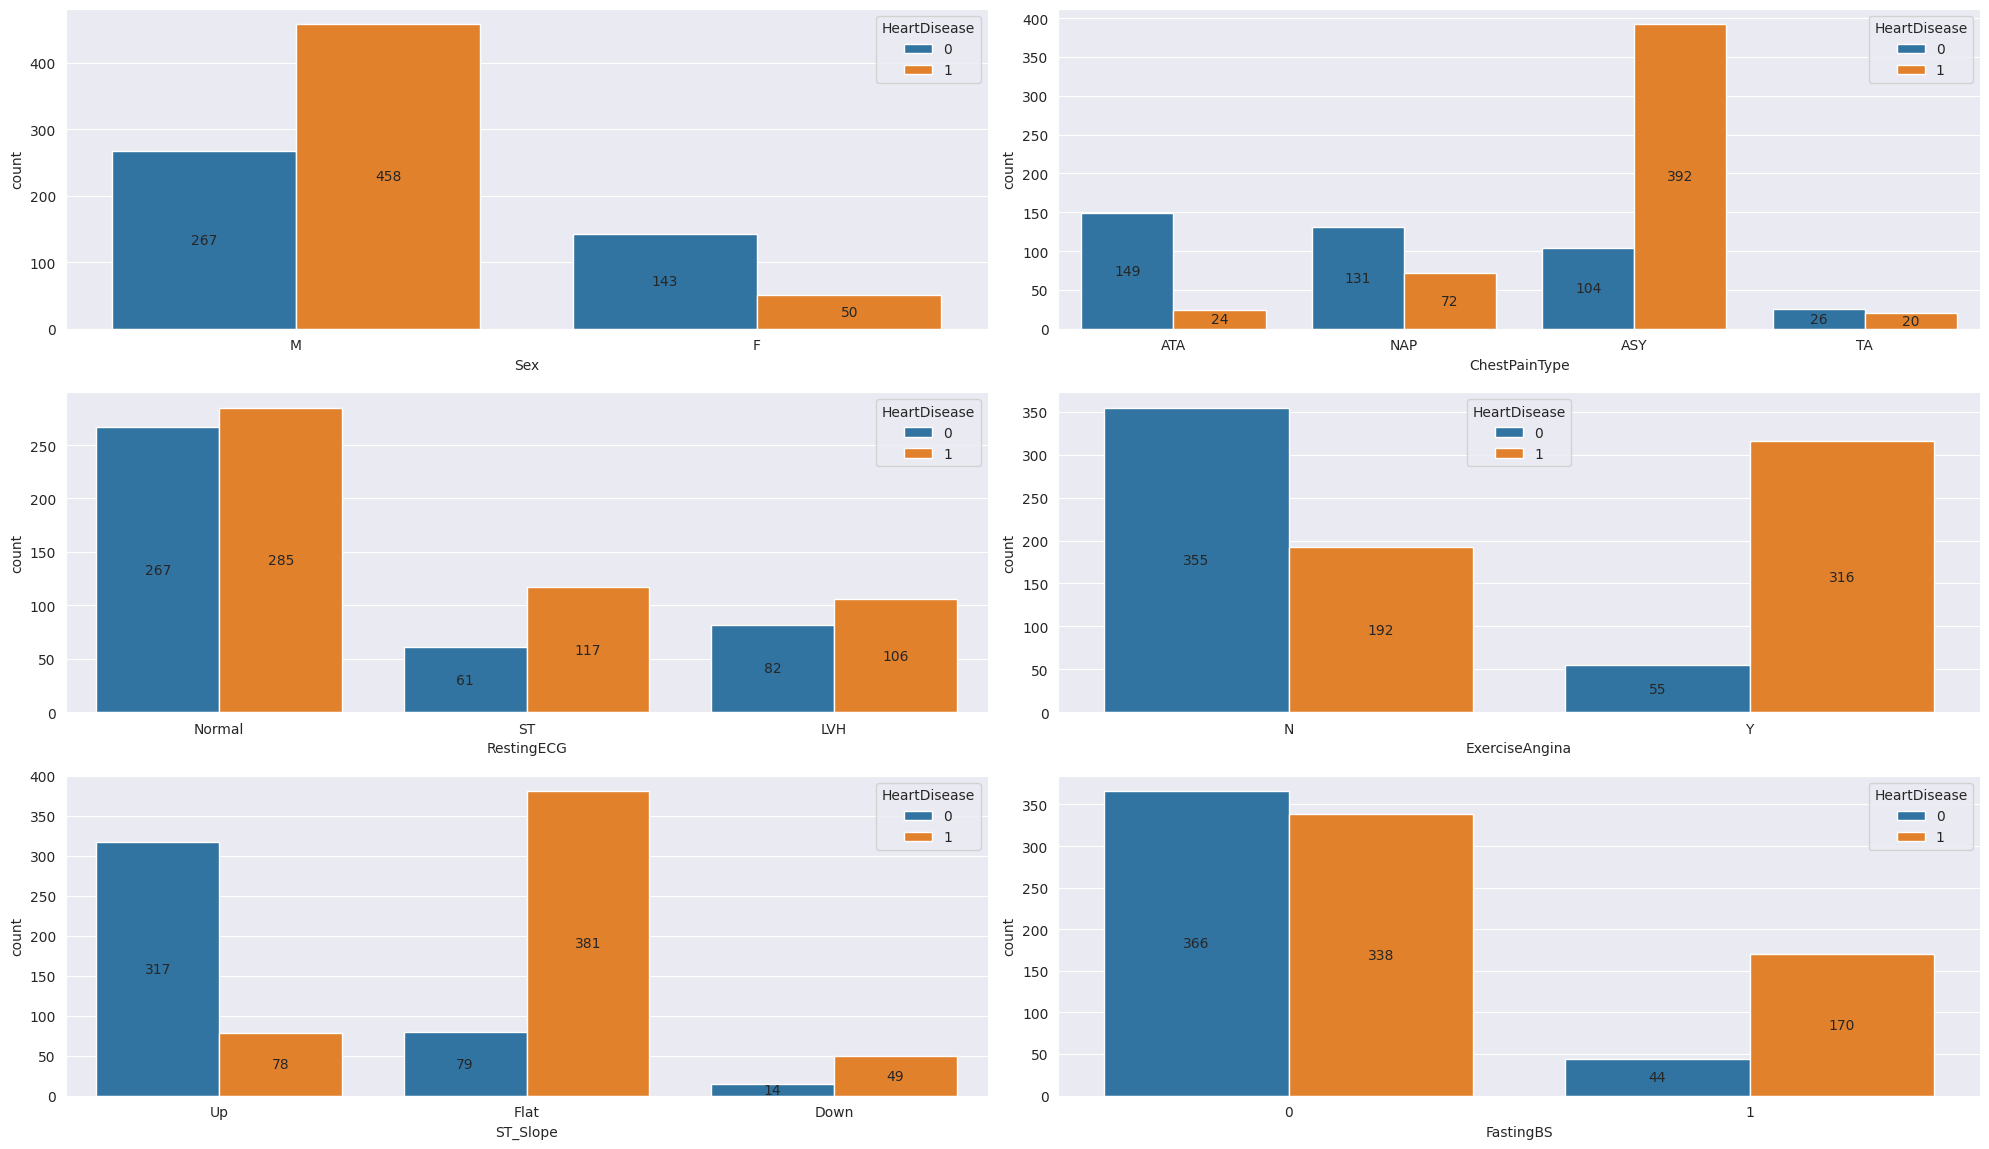

In [ ]:
# plot how categorical varialble relate to predicted variable
fig = plt.figure(figsize=(20, 15))

for idx, col in enumerate(categorical_cols[:-1]):
  ax = plt.subplot(4, 2, idx + 1)
  # Group by heart disease
  sns.countplot(x=heart_df[col], hue = heart_df['HeartDisease'], ax=ax)
  # add data labels to each bar
  for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.tight_layout()

In [ ]:
# # Generate a profiling report
# profile_report = ProfileReport(heart_df, title="Pandas Profiling Report", explorative=True)
# profile_report.to_notebook_iframe()

# # Generate the profiling report
# profile_report.to_file("pandas_profiling_report.html")

## Data Cleaning

In [ ]:
# Show number of rows before handling outliers
print("Number of rows before handling outliers:", heart_df.shape[0])

Number of rows before handling outliers: 918


In [ ]:
# use Z score to check for outliers
from scipy.stats import zscore

# Assume df is your cleaned, log-transformed DataFrame
columns_to_check = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
df_subset = heart_df[columns_to_check]

# Calculate Z-scores
z_scores = np.abs(zscore(df_subset))

# Define threshold
threshold = 3

# Count outliers per column
outliers_per_column = (z_scores > threshold).sum(axis=0)

# Count total rows with at least one outlier
rows_with_outliers = (z_scores > threshold).any(axis=1).sum()

# Count total individual outlier cells across all features
total_outlier_cells = (z_scores > threshold).sum().sum()

# Display results
print("Outliers per column:\n", pd.Series(outliers_per_column, index=columns_to_check))
print("\nTotal rows with at least one outlier:", rows_with_outliers)
print("Total individual outlier cells:", total_outlier_cells)

Outliers per column:
 Age            0
RestingBP      8
Cholesterol    3
FastingBS      0
MaxHR          1
Oldpeak        7
dtype: int64

Total rows with at least one outlier: 19
Total individual outlier cells: 19


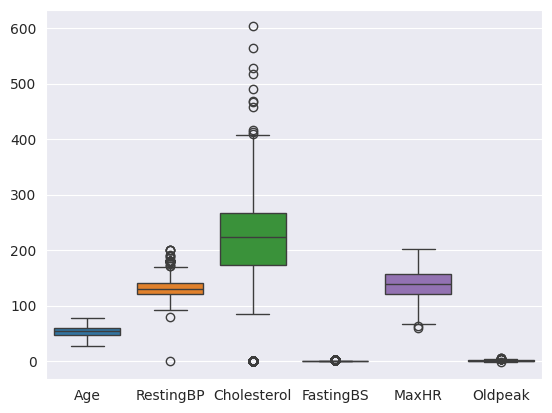

In [ ]:
# plot box plot to detect outliers
sns.boxplot(data=df_subset)
plt.show()

In [ ]:
# removing outliers
# Create the boolean mask for outliers based on the calculated z_scores
outliers = (z_scores > threshold).any(axis=1)

# Use the created mask to filter out rows with outliers
data = heart_df[~outliers]
print("New shape after removing outliers:", data.shape)

New shape after removing outliers: (899, 12)


In [ ]:
# check how many instances "RestingBP" has zeros
data[data['RestingBP'] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             0 non-null      int64  
 1   Sex             0 non-null      object 
 2   ChestPainType   0 non-null      object 
 3   RestingBP       0 non-null      int64  
 4   Cholesterol     0 non-null      int64  
 5   FastingBS       0 non-null      int64  
 6   RestingECG      0 non-null      object 
 7   MaxHR           0 non-null      int64  
 8   ExerciseAngina  0 non-null      object 
 9   Oldpeak         0 non-null      float64
 10  ST_Slope        0 non-null      object 
 11  HeartDisease    0 non-null      int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 0.0+ bytes


In [ ]:
# check how many instances "Cholesterol" has zeros
data[data['Cholesterol'] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 167 entries, 293 to 536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             167 non-null    int64  
 1   Sex             167 non-null    object 
 2   ChestPainType   167 non-null    object 
 3   RestingBP       167 non-null    int64  
 4   Cholesterol     167 non-null    int64  
 5   FastingBS       167 non-null    int64  
 6   RestingECG      167 non-null    object 
 7   MaxHR           167 non-null    int64  
 8   ExerciseAngina  167 non-null    object 
 9   Oldpeak         167 non-null    float64
 10  ST_Slope        167 non-null    object 
 11  HeartDisease    167 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 17.0+ KB


In [ ]:
# Make a copy of the dataframe
df_clean = data.copy()

df_clean = df_clean[df_clean['RestingBP'] != 0]

In [ ]:
# fill cholestrol zero values with median
heartdisease_mask = df_clean['HeartDisease'] == 0

cholestrol_without_heartdisease = df_clean.loc[heartdisease_mask, 'Cholesterol']
cholestrol_with_heartdisease = df_clean.loc[~heartdisease_mask, 'Cholesterol']

df_clean.loc[heartdisease_mask, 'Cholesterol'] = cholestrol_without_heartdisease.replace(to_replace=0, value=cholestrol_without_heartdisease.median())
df_clean.loc[~heartdisease_mask, 'Cholesterol'] = cholestrol_with_heartdisease.replace(to_replace=0, value=cholestrol_with_heartdisease.median())

/tmp/ipython-input-368172275.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[180.  214.  207.  164.  234.  196.  248.  267.  288.  518.  224.  172.
 306.  294.  175.  289.  233.  205.  270.  213.  342.  277.  246.  265.
 182.  268.  206.  223.  213.  139.  263.  291.  329.  263.  275.  392.
 466.  186.  255.  246.  282.  338.  156.  248.  393.  202.  388.  230.
 265.  166.  247.  331.  341.  291.  279.  342.  190.  290.  264.  212.
 272.  266.  288.  216.  225.  404.  211.  237.  285.  246.  257.  216.
 263.  288.  226.  280.  222.  303.  264.  117.  336.  295.  355.  193.
 292.  268.  237.  275.  219.  341.  491.  260.  248.  231.  126.  193.
 298.  242.  201.  160.  223.  222.  216.5 216.5 216.5 216.5 216.5 216.5
 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5
 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5 216.5
 216.5 216.5 216.5 216.5 216.5 216.5 216.

In [ ]:
# describe "RestingBP" and "Cholesterol"
df_clean[['RestingBP', 'Cholesterol']].describe()

,RestingBP,Cholesterol
count,899.000000,899.000000
mean,132.027809,238.456618
std,17.120895,51.266589
min,80.000000,85.000000
25%,120.000000,214.000000
50%,130.000000,225.000000
75%,140.000000,266.000000
max,185.000000,518.000000


## Correlation

In [ ]:
# encode categorical variables to numeric
df_clean = pd.get_dummies(df_clean, drop_first=True)
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


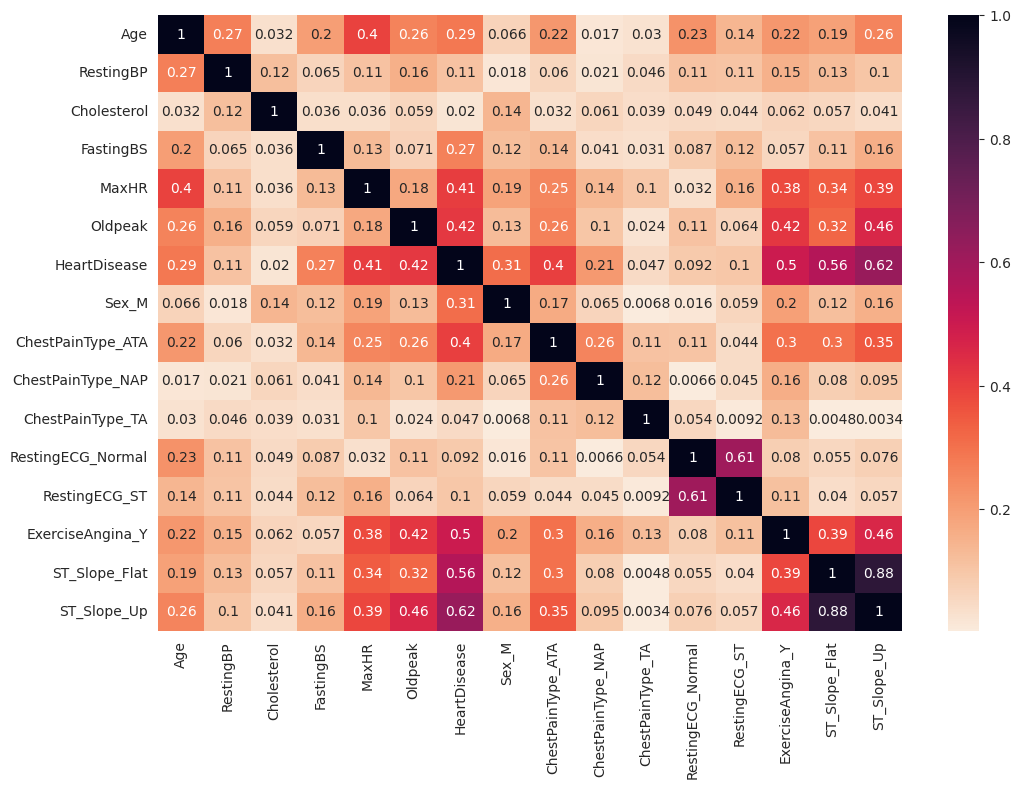

In [ ]:
# plot correlation heatmap
correlations = abs(df_clean.corr())
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, annot=True, cmap='rocket_r')
plt.show()

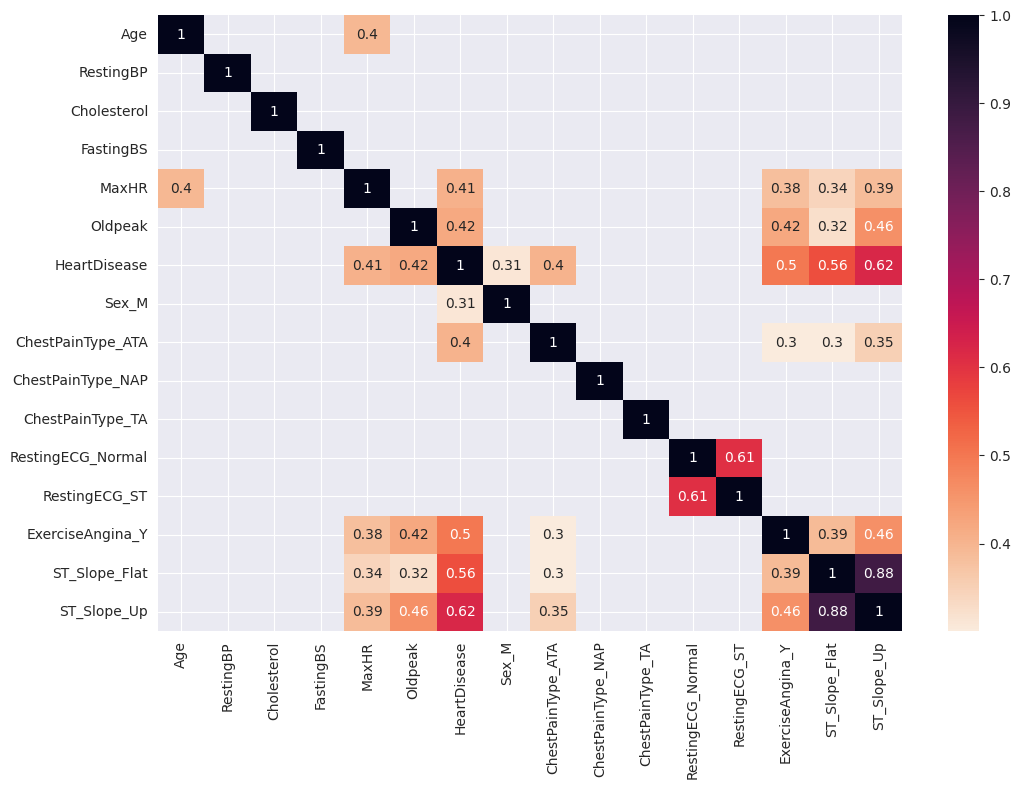

In [ ]:
# plot correlation matrix for value > 0.3
plt.figure(figsize=(12, 8))
sns.heatmap(correlations[correlations > 0.3], annot=True, cmap='rocket_r')
plt.show()

# Data Visualization

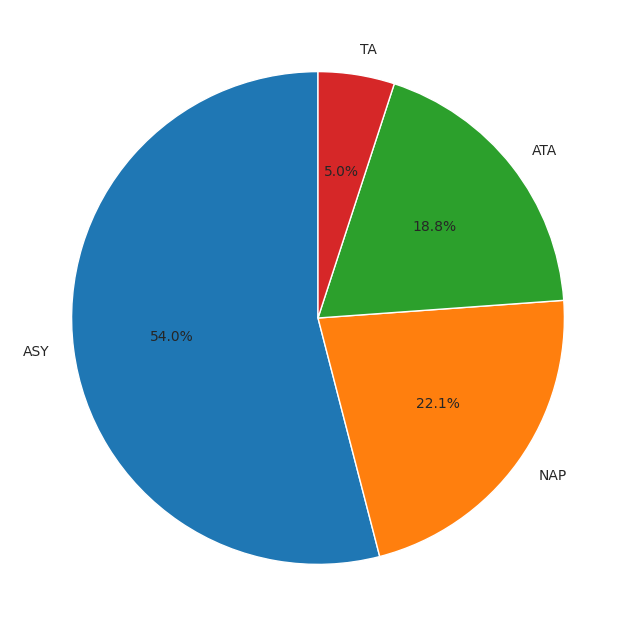

In [ ]:
# plot a pie chart for "ChestPainType"
chest_pain_counts = heart_df['ChestPainType'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(chest_pain_counts, labels=chest_pain_counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

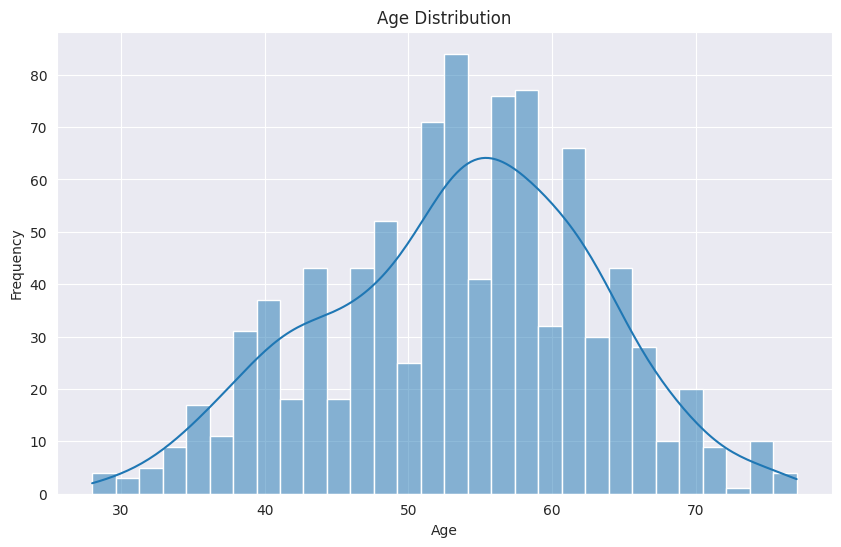

In [ ]:
# plot a histogram of Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(heart_df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

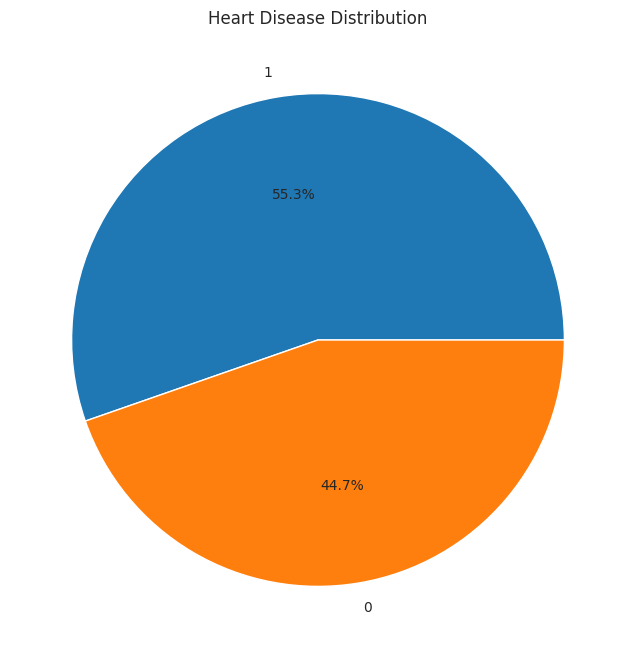

In [ ]:
# plot pie chart of distribution of "HeartDisease"
heart_df['HeartDisease'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Heart Disease Distribution')
plt.ylabel('')
plt.show()

Text(0, 0.5, 'Count')

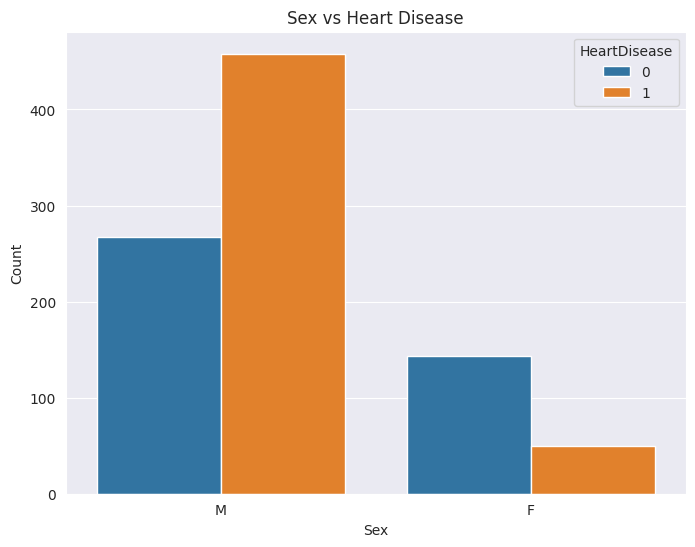

In [ ]:
# plot showing sex with HeartDisease
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='HeartDisease', data=heart_df)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex')
plt.ylabel('Count')

# Building Machine Learning Model using Random Forest

In [ ]:
df_clean.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,172,0.0,0,True,False,False,True
1,49,160,180.0,156,1.0,1,False,False,True,False
2,37,130,283.0,98,0.0,0,True,False,False,True
3,48,138,214.0,108,1.5,1,False,True,True,False
4,54,150,195.0,122,0.0,0,False,False,False,True


In [ ]:
# Splitting train / Test sets
X = df_clean.drop(['HeartDisease'], axis=1)
y = df_clean['HeartDisease']

In [ ]:
#Train our model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale and fit the model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Random classifier
rf = RandomForestClassifier(n_estimators = 100,  random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# make predictions
y_pred = rf.predict(X_test)

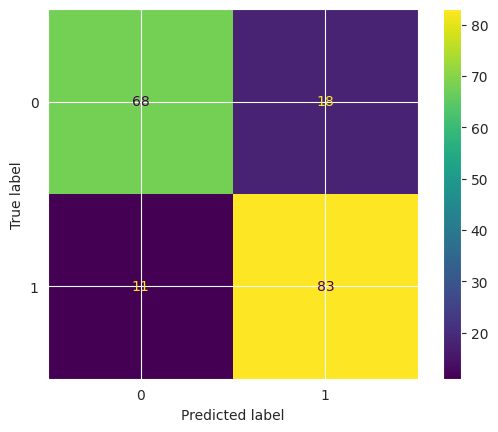

In [ ]:
# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [ ]:
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print("\nClassification Report:\n", class_report)
print(f"\nAccuracy Score: {accuracy*100:.2f}%")


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82        86
           1       0.82      0.88      0.85        94

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180


Accuracy Score: 83.89%


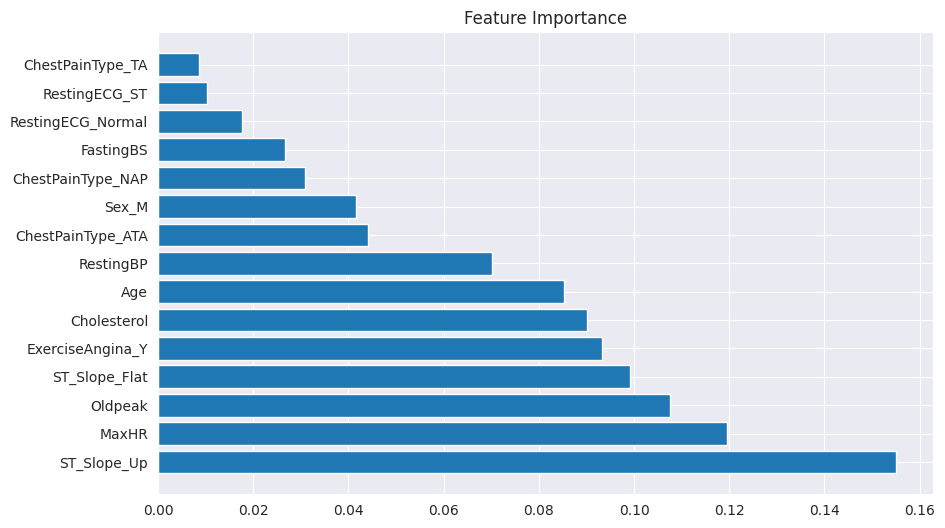

In [ ]:
# Visualize feature importance
feature_importances = rf.feature_importances_
indices = np.argsort(feature_importances)[::-1]
names = [X.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.barh(range(X.shape[1]), feature_importances[indices])
plt.yticks(range(X.shape[1]), names)
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# Load and preprocess dataset
# -------------------------------
@st.cache_data
def load_data():
    heart_df = pd.read_csv("heart.csv")

    # Clean RestingBP
    df = heart_df.copy()
    df = df[df["RestingBP"] != 0]

    # Fill Cholesterol zeros with median
    mask = df["HeartDisease"] == 0
    chol_no_hd = df.loc[mask, "Cholesterol"]
    chol_hd = df.loc[~mask, "Cholesterol"]
    df.loc[mask, "Cholesterol"] = chol_no_hd.replace(0, chol_no_hd.median())
    df.loc[~mask, "Cholesterol"] = chol_hd.replace(0, chol_hd.median())

    # Encode categoricals
    df = pd.get_dummies(df, drop_first=True)

    # Keep only 9 features
    features = [
        "MaxHR",
        "Oldpeak",
        "Age",
        "Cholesterol",
        "ChestPainType_ATA",
        "RestingECG_Normal",
        "ExerciseAngina_Y",
        "ST_Slope_Flat",
        "ST_Slope_Up",
    ]
    return df, features

df, features = load_data()

X = df[features]
y = df["HeartDisease"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# -------------------------------
# Streamlit UI
# -------------------------------
st.title("❤️ Heart Disease Prediction App")
st.write("This app predicts the likelihood of heart disease using 9 input features.")

st.sidebar.header("Enter Patient Data")

# Sidebar input fields
Age = st.sidebar.slider("Age", 20, 100, 50)
Cholesterol = st.sidebar.slider("Cholesterol", 100, 400, 200)
MaxHR = st.sidebar.slider("Max Heart Rate", 60, 200, 150)
Oldpeak = st.sidebar.slider("ST Depression (Oldpeak)", -2.0, 6.0, 1.0)

ChestPainType_ATA = st.sidebar.checkbox("Chest Pain: ATA", False)
RestingECG_Normal = st.sidebar.checkbox("Resting ECG: Normal", False)
ExerciseAngina_Y = st.sidebar.checkbox("Exercise Angina: Yes", False)
ST_Slope_Flat = st.sidebar.checkbox("ST Slope: Flat", False)
ST_Slope_Up = st.sidebar.checkbox("ST Slope: Up", False)

# Collect inputs into a DataFrame
input_df = pd.DataFrame(
    {
        "MaxHR": [MaxHR],
        "Oldpeak": [Oldpeak],
        "Age": [Age],
        "Cholesterol": [Cholesterol],
        "ChestPainType_ATA": [int(ChestPainType_ATA)],
        "RestingECG_Normal": [int(RestingECG_Normal)],
        "ExerciseAngina_Y": [int(ExerciseAngina_Y)],
        "ST_Slope_Flat": [int(ST_Slope_Flat)],
        "ST_Slope_Up": [int(ST_Slope_Up)],
    }
)

# Scale input
input_scaled = scaler.transform(input_df)

# Prediction
prediction = rf.predict(input_scaled)
prediction_proba = rf.predict_proba(input_scaled)

# Show results
st.subheader("Prediction Result")
if prediction[0] == 0:
    st.success("✅ No Heart Disease")
else:
    st.error("⚠️ Likely Heart Disease")

st.subheader("Prediction Probability")
st.write(f"No Heart Disease: {prediction_proba[0][0]*100:.2f}%")
st.write(f"Heart Disease: {prediction_proba[0][1]*100:.2f}%")

st.subheader("Model Accuracy on Test Data")
st.write(f"Accuracy: {accuracy*100:.2f}%")


Overwriting app.py


In [ ]:
!pip install streamlit pyngrok -q

In [ ]:
! wget -q -O - ipv4.icanhazip.com

35.196.221.195


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.196.221.195:8501

⠇⠏⠋⠙⠹your url is: https://proud-showers-sing.loca.lt
